In [39]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

In [40]:
(x_train,y_train),(x_test,y_test) = cifar10.load_data()

In [41]:
x_train.shape

(50000, 32, 32, 3)

In [42]:
x_test.shape

(10000, 32, 32, 3)

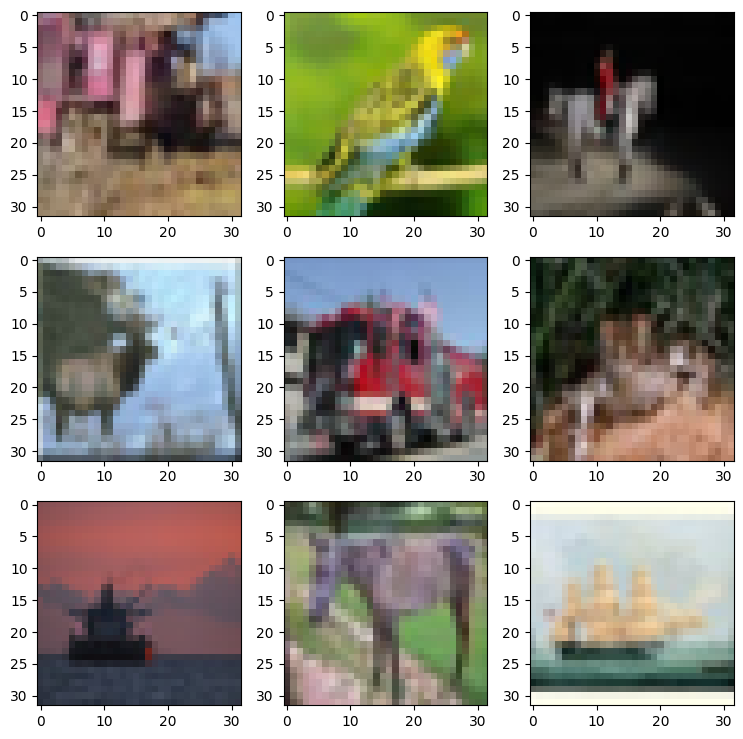

In [43]:
plt.figure(figsize=(9,9))
amostras = np.random.choice(x_train.shape[0],9)
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(x_train[amostras[i]])

plt.show()

In [44]:
df = np.concatenate([x_train,x_test],axis=0)
df = df.astype("float32") / 255

In [45]:
class SamplingLayer(layers.Layer):
  # o reparameterization trick nao muda conforme os dados é genérico entao ele é identico ao do video
  def call(self, inputs):
    zMean, zLogVar = inputs# pega a media e o log de variancia
    batch = tf.shape(zMean)[0]# lote de imagens
    dim = tf.shape(zMean)[1]# dimensao da meadia
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return zMean + tf.exp(0.5 * zLogVar) * epsilon

In [46]:
def encoder(latentdim,encoderinputs):
  layer1 = tf.keras.models.Sequential([
      layers.Conv2D(128,3,activation='relu',strides=2,padding='same'),# camada de convolução com 128 feature maps, 3 canais pois é RGB
      layers.Conv2D(64,3, activation='relu',strides=2,padding='same'),
      layers.Conv2D(32,3,activation='relu',strides=2,padding='same'),
      layers.Flatten(),# achata tudo para um vetor
      layers.Dense(256,activation='relu')#camada densa de 256 neuuronios
  ])
  x=layer1(encoderinputs)# instancia a primeira camada
  zMean = layers.Dense(latentdim)(x)# calcular a zmedia
  logVar = layers.Dense(latentdim)(x)# logvar
  z = SamplingLayer()([zMean,logVar])# calculando a distribuição
  return tf.keras.Model(encoderinputs, [zMean, logVar,z])# retorna o modeo com as camdas do encoder

In [47]:
encoderinputs = tf.keras.Input(shape=(32,32,3))
# define o tamanho da imagem como entrada para a rede
encoder = encoder(16,encoderinputs)
# chamando a funcao encoder para 2 dimensoes de espaco latente
encoder.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 256)       │    227,168 │ input_layer_8[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16)        │      4,112 │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │      4,112 │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_layer_2    │ (None, 16)        │          0 │ dense_9[0][0],    │
│ (SamplingLayer)     │                   │            │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 235,392 (919.50 KB)

 Trainable params: 235,392 (919.50 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
def decoder(latentInputs):
  layer1 = tf.keras.models.Sequential([
    layers.Dense(4*4*32, activation="relu", input_shape=(latentInputs.shape[1],)),# camada de entrada ao decoder com ela 4x4 e 32 canais
    layers.Reshape((4,4,32)),# colocando no formato
    layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same"),#sequencia de camadas de concolucao transpostas, para aumentar a imagem invés de diminuir igual ao encoder
    layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")# usando sigmoois para retornar algum valor dentre o canal normalizado
  ])
  return tf.keras.Model(latentInputs, layer1(latentInputs))#retorna o modelo com o input do espaco latente

latentInputs = tf.keras.Input(shape=(16,))#espaco latente igual a 2 por isso o shape
decoder = decoder(latentInputs)# acionando a funcao decoder
decoder.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 32, 32, 3)      │       113,763 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,763 (444.39 KB)

 Trainable params: 113,763 (444.39 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
def reconstructionLoss(data, reconstructed):
  #funcoes de loss, seguem as mesmas dos videos pois seguem uma formula padrao
  # funcao de reconstrucao
  return tf.reduce_mean(
      tf.reduce_sum(
          tf.keras.losses.binary_crossentropy(data, reconstructed),
          axis=(1, 2)
      )
  )
# calula a distancia entre as distribuicoes de probabilidade
def klDivergenceLoss(zMean, zLogVar):
  return tf.reduce_mean(
      tf.reduce_sum(
          -0.5 * (1 + zLogVar - tf.square(zMean) - tf.exp(zLogVar)),
          axis=1
      )
  )

In [50]:
def CtotalLoss(data, reconstructed, zMean, zLogVar):
  loss1 = reconstructionLoss(data, reconstructed)
  # calculando a funcao de reconstrucao com a imagem original e a reconstruida
  loss2 = klDivergenceLoss(zMean, zLogVar)
  # calculando a distancia entre as distribuicoes de origem com a reconstruida
  klWeight = 4.0
  # peso do kl
  return loss1, loss2, loss1 + klWeight * loss2

In [51]:
class VAE(tf.keras.Model):
  # mesmo padrao de treino utilizado no video, pois é uma forma generica de treinar e nao precisa de ajuste
  def __init__(self, encoder, decoder, **kwargs):
    super(VAE, self).__init__(**kwargs)
    self.encoder = encoder
    self.decoder = decoder
    self.totalLossTracker = tf.keras.metrics.Mean(name="total_loss")
    self.ceLossTracker = tf.keras.metrics.Mean(name="ce_loss")
    self.klLossTracker = tf.keras.metrics.Mean(name="kl_loss")

  @property
  def metrics(self):
    return [self.totalLossTracker, self.ceLossTracker, self.klLossTracker]

  def train_step(self, data):
    # aqui tudo vai ser aplicado a o  gradiente onde depois sera pego os pesos, as funcoes de perda e tambem ajustado o gradiente
    with tf.GradientTape() as tape:
        zMean, zLogVar, z = self.encoder(data)
        reconstruction = self.decoder(z)
        ceLoss, klLoss, totalLoss = CtotalLoss(data, reconstruction, zMean, zLogVar)
    grads = tape.gradient(totalLoss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
    self.totalLossTracker.update_state(totalLoss)
    self.ceLossTracker.update_state(ceLoss)
    self.klLossTracker.update_state(klLoss)
    return {"total_loss": self.totalLossTracker.result(),"ce_loss": self.ceLossTracker.result(),"kl_loss": self.klLossTracker.result()}

In [52]:
vae = VAE(encoder,decoder)#instanciando o modelo com as funcoes encoder e decoder
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))#compilando com os hiperparametros
model_treino = vae.fit(df,epochs=128,batch_size=128)# treino do modelo

Epoch 1/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - ce_loss: 666.9926 - kl_loss: 2.7684 - total_loss: 678.0663
Epoch 2/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - ce_loss: 644.7655 - kl_loss: 4.0928 - total_loss: 661.1371
Epoch 3/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - ce_loss: 641.1699 - kl_loss: 4.5019 - total_loss: 659.1772
Epoch 4/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - ce_loss: 639.9427 - kl_loss: 4.6299 - total_loss: 658.4623
Epoch 5/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - ce_loss: 639.1949 - kl_loss: 4.7198 - total_loss: 658.0742
Epoch 6/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - ce_loss: 638.4684 - kl_loss: 4.7770 - total_loss: 657.5767
Epoch 7/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - ce_loss: 637.7342 - kl_loss: 4.8808 - total_loss: 657.2572
Epoch 8/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - ce_loss: 636.6868 - kl_loss: 5.0512 - total_loss: 656.8910
Epoch 9/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - ce_loss: 635.3803 - kl_

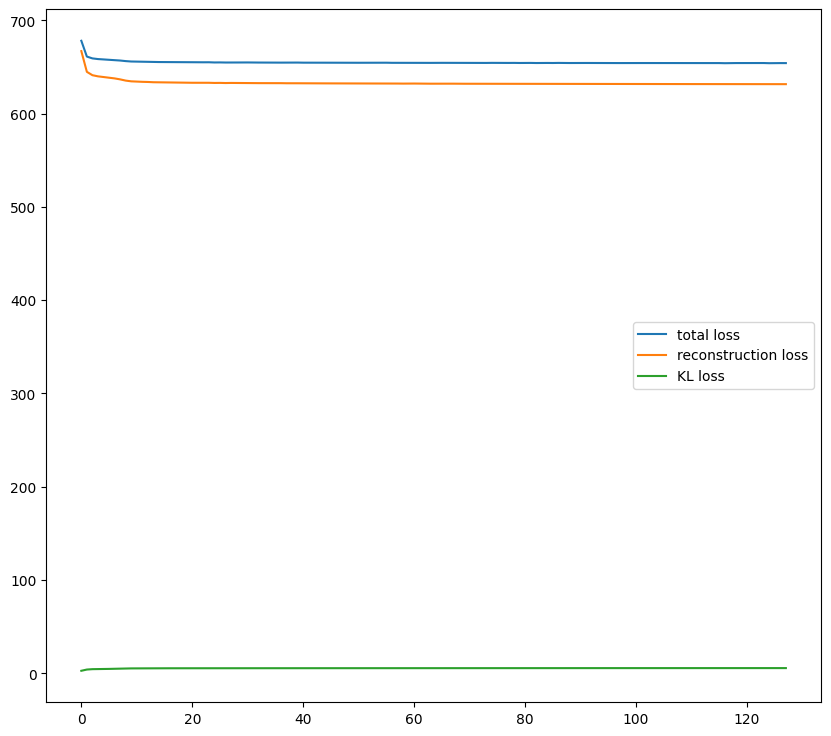

In [53]:
plt.figure(figsize=(10, 9))
# loss durante o treino
plt.plot(model_treino.history.get('total_loss'), label="total loss")
plt.plot(model_treino.history.get('ce_loss'), label="reconstruction loss")
plt.plot(model_treino.history.get('kl_loss'), label="KL loss")
plt.legend()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


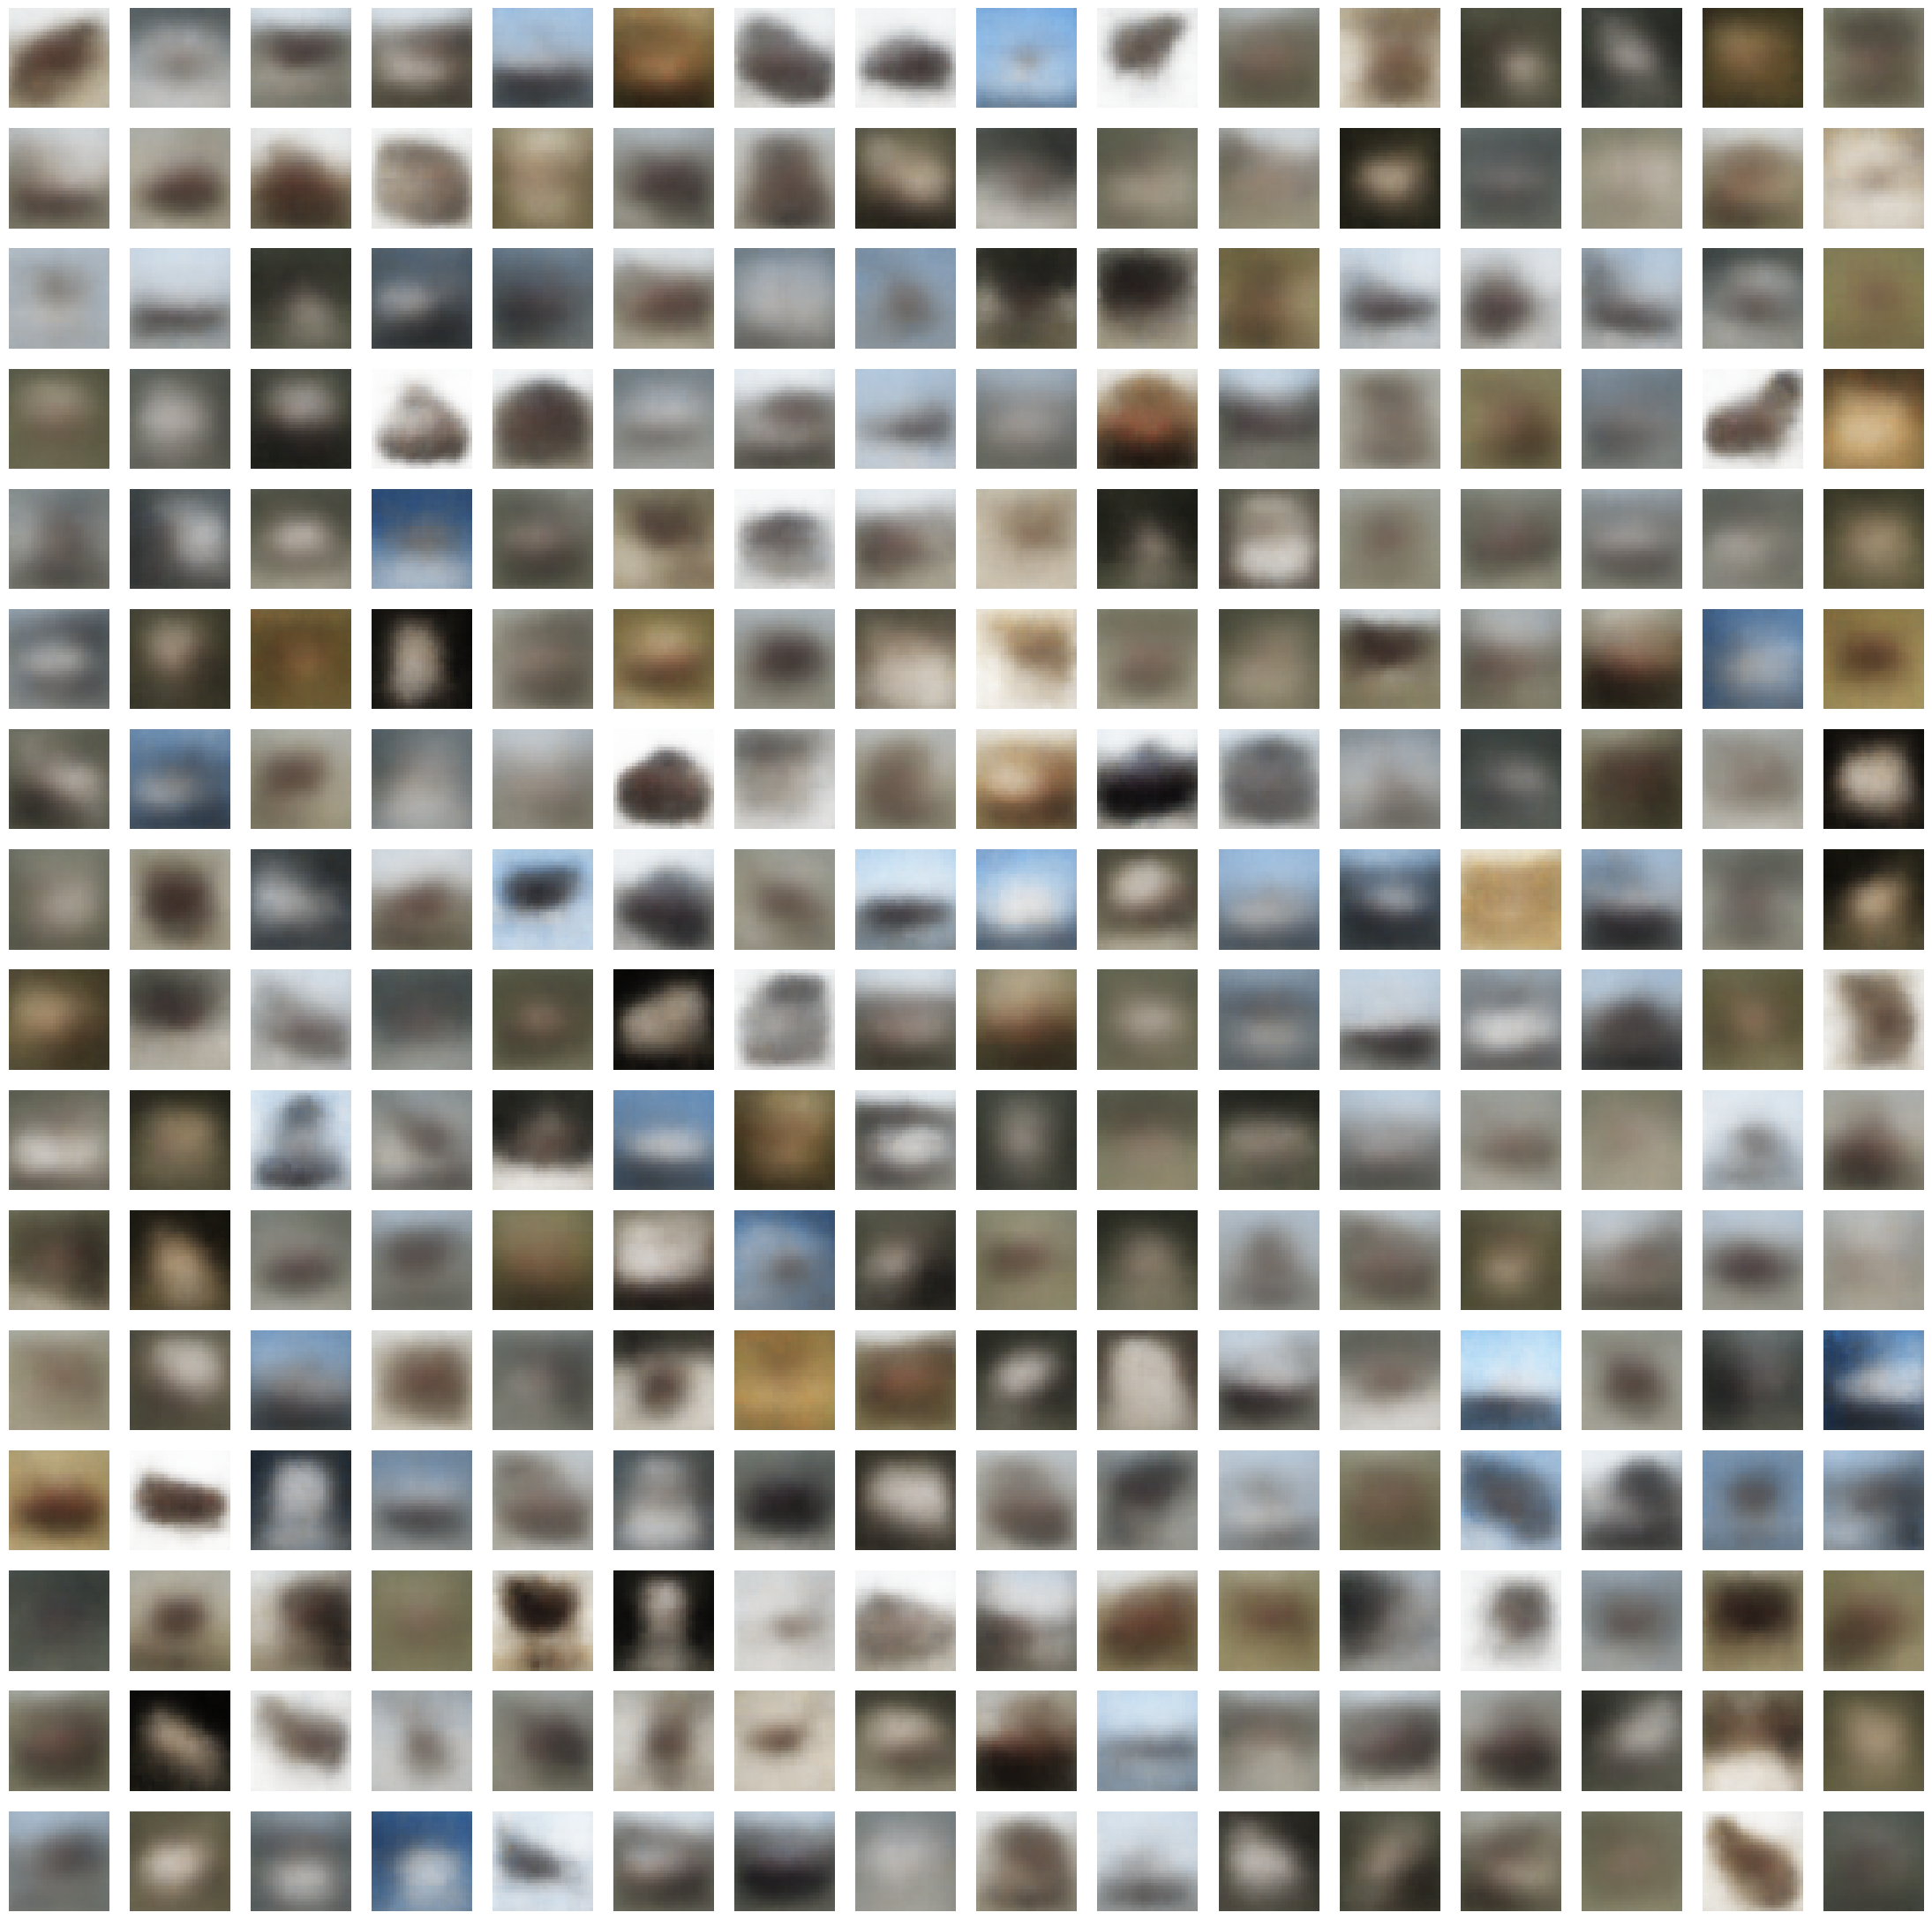

In [58]:
z = np.random.normal(loc=0, scale=1, size=(256,16))
# gerando 256 imagens a partir da distribuição
pred = vae.decoder.predict(z)
# previsao da imagem com o decodeer, pois so e necessario reconstruir
plt.figure(figsize=(28,28))
#mostrado as imagens criadas
for i in range(256):
    plt.subplot(16,16,i+1)
    plt.imshow(pred[i])
    plt.axis('off')
plt.show()

In [59]:
label =np.concatenate([y_train, y_test], axis=0).flatten()
#juntando os dados de testes, o flatten e necessario pois o label do cifar 10 vem como um array2d

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


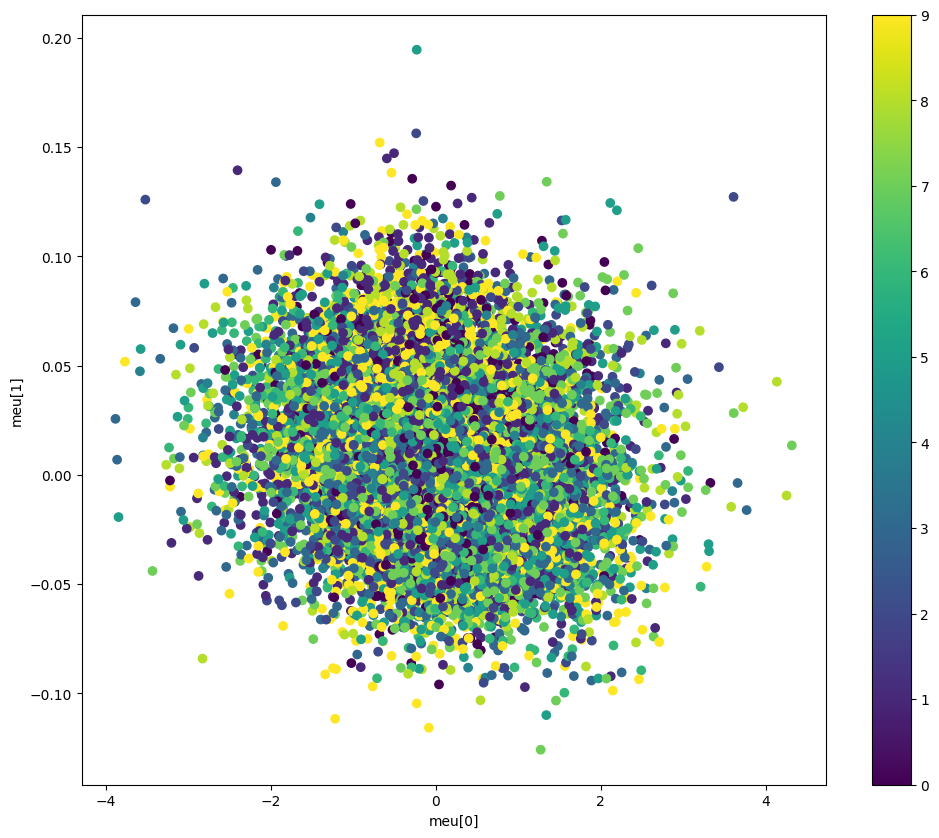

In [60]:
#espaco latente no grafico
meu, _, _ = vae.encoder.predict(df)
plt.figure(figsize=(12, 10))
plt.scatter(meu[:, 0], meu[:, 1], c=label)
plt.colorbar()
plt.xlabel("meu[0]")
plt.ylabel("meu[1]")
plt.show()